In [185]:
import numpy as np

import sys
sys.path.append('../')
from core import LADTransferTreeBoost, LSTransferTreeBoost, MTransferTreeBoost
import pandas as pd
from sklearn.model_selection import train_test_split
from baselines import *

In [186]:
from ucimlrepo import fetch_ucirepo 
  
# fetch dataset 
abalone = fetch_ucirepo(id=925) 
  
# data (as pandas dataframes) 
X = abalone.data.features 
y = abalone.data.targets['aveOralF']
  
print(f'Amount of features: {X.shape[1]}, amount of datapoints: {X.shape[0]}')

Amount of features: 33, amount of datapoints: 1020


In [187]:
# Order DataFrame by this value
data = X.copy()
data['aveOralF'] = y #add this to the entire data, as we will order them
# Convert object columns to category first
for col in data.select_dtypes(include='object').columns:
    data[col] = data[col].astype('category')

# Now convert category columns to numeric codes
for col in data.select_dtypes(include='category').columns:
    data[col] = data[col].cat.codes



In [188]:
target_column = 'aveOralF'
predictor_columns = list(X.columns)

In [189]:
#Identify each correlation with target variable
single_features = []
features = []
corr_coefs = []
for feature in X.columns:
    single_feature = X[feature]
    single_features.append(single_feature)
    features.append(feature)
    if np.issubdtype(single_feature.dtype, np.number):
        corr_coef = float(np.corrcoef(single_feature, y)[0,1])
    else:
        corr_coef = 0
    corr_coefs.append(corr_coef)

# Select the variable that has correlation closest to 0.4
idx = min(range(len(corr_coefs)), key=lambda i: abs(corr_coefs[i] - 0.4))
closest_value = corr_coefs[idx]
selected_variable = X.columns[idx]

#sort by this value, and remove the column!
data = data.sort_values(by = selected_variable)
data = data.drop(columns = selected_variable)
predictor_columns.remove(selected_variable)

# Split data into three equally sized components
n = len(data)
t = n // 3  # size of each part

df1 = data.iloc[:t]
df2 = data.iloc[t:2*t]
df3 = data.iloc[2*t:]

#randomly select the target set
df = [df1, df2, df3]
random_index = np.random.choice(3)
data_target = df[random_index]
data_source = pd.concat([df[i] for i in range(3) if i != random_index], ignore_index=True)



In [190]:
data_train, data_test = train_test_split(data_target, test_size=0.1, random_state=34)

X_source_train = np.array(data_source[predictor_columns])
y_source_train = np.array(data_source[target_column]) #change this to "Dgv" to use diameter as source label!

#Specific train and test set
X_target_train = np.array(data_train[predictor_columns])
y_target_train = np.array(data_train[target_column])

X_target_test = np.array(data_test[predictor_columns])
y_target_test = np.array(data_test[target_column])

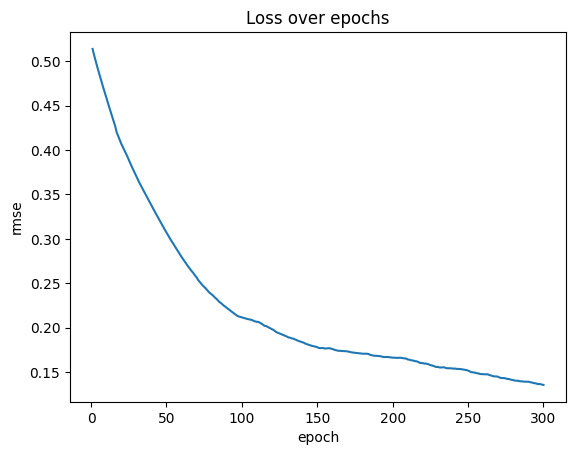

0.395784014227241


In [191]:
fiter = MTransferTreeBoost(epochs=300, k = 0.01)
fiter.fit(X_target_train, y_target_train, X_source_train, y_source_train, show_curves = True)
rmse = fiter.evaluate(X_target_test, y_target_test, metric = 'rmse')
mae = fiter.evaluate(X_target_test, y_target_test, metric = 'mae')

print(rmse)

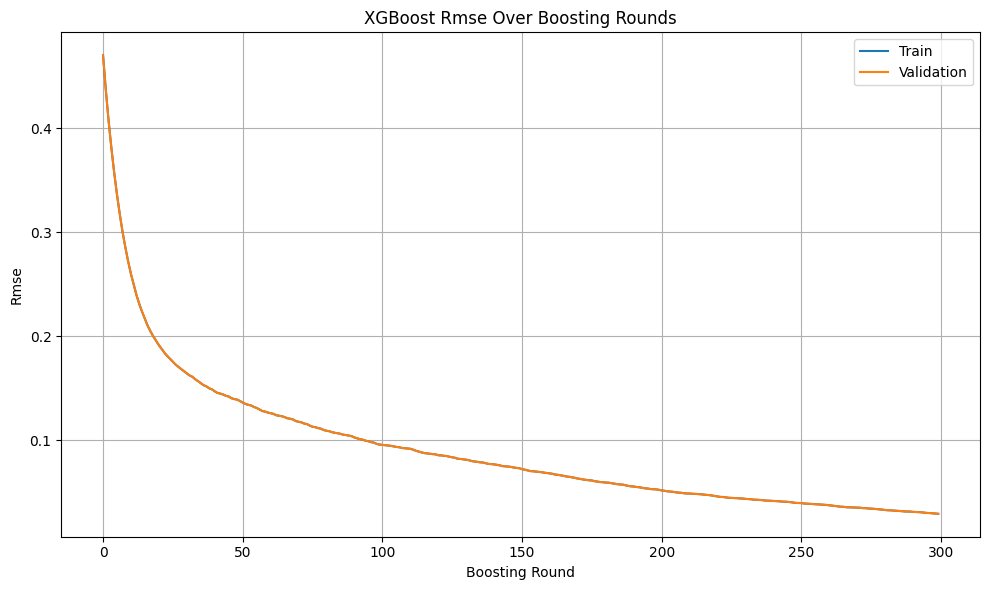

0.413759344611063


In [192]:
params = {
    'objective': 'reg:squarederror',  # Regression with squared error
    'max_depth': 3,                   # Maximum depth of a tree
    'eta': 0.1,                       # Learning rate
    'eval_metric': 'rmse',           # RMSE as evaluation metric
    }
        
bst = train_xgboost(X_target_train, y_target_train, X_target_train, y_target_train, boosting_rounds=300, params=params, early_stopping_rounds=500, show_curve=True)
preds = test_xgboost(X_target_test, bst)
rmse = compute_rmse(preds, y_target_test)
mae = compute_mae(preds, y_target_test)

print(rmse)